# Does the perturbation push neural activity into a higher-dimensional space?

**Prior result (calcium + ridge):** unperturbed neural trajectories lie on a
low-dimensional plane; perturbed trajectories *leave* it (larger off-plane angle
at every time step).

**Here (PLDS):** the inferred latent `s_t` is the model's denoised low-D state
(the analog of "calcium after PCA"), and the perturbation enters the latent
*only* through the gated drive `dG`:

$$ s_t = F s_{t-1} + \sum_\ell G_\ell z_{t-\ell} + u_{t-\ell}\sum_\ell \delta G_\ell z_{t-\ell} + m_s + \text{noise},\qquad x_t \sim \text{Poisson}(\Delta e^{C s_t + b}). $$

We test three claims:
- **A.** Perturbed latents escape the unperturbed manifold (time-resolved angle).
- **B.** Perturbed trials need *more* latent dimensions (participation ratio).
- **C.** This extra dimensionality is *caused* by `dG`, holding kinematics fixed
  (counterfactual simulation) — something the calcium ridge regression cannot show.

In [1]:
import pickle, numpy as np, matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, wilcoxon
from perturbation_plds import manifold_analysis as ma

with open("perturbation_plds_results/session0/fit_p10.pkl", "rb") as f:
    cache = pickle.load(f)

F, Q, m_s = cache["F"], cache["Q"], cache["m_s"]
G_lag, dG_lag = cache["G_lag"], cache["dG_lag"]
p, J = cache["p"], cache["J"]
latents = cache["latents"]            # list of (T-J, p), inferred E[s_t]
u_trim  = cache["u_trim"]             # per-trial indicator aligned to latents
Z_full, U_full = cache["Z_full"], cache["U_full"]   # untrimmed, for rollout

pert, unpert = ma.split_perturbed(u_trim)
onsets = {i: ma.perturbation_onset(u_trim[i]) for i in pert}  # trimmed index
print(f"p={p}  J={J}  trials: {len(pert)} perturbed, {len(unpert)} unperturbed")
print(f"latent length T-J = {latents[0].shape[0]}; ELBO {cache['elbo_trace'][-1]:.0f}")
print("onset (trimmed) median:", int(np.median([o for o in onsets.values()])))

/home/sp645/miniconda3/envs/ssm/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


p=10  J=3  trials: 60 perturbed, 80 unperturbed
latent length T-J = 165; ELBO -891033
onset (trimmed) median: 53


## A. Off-manifold angle (direct replica of the calcium figure)

Build the **unperturbed manifold** from a *training* half of unperturbed trials
(top-k PCs, 90% variance), then measure, for every state, the angle off that
manifold: `arcsin(||s_perp|| / ||s||)`. Using held-out unperturbed trials guards
against circularity — they should stay *on*-manifold while perturbed trials leave.

unperturbed manifold dimension k = 5 (of p=10)


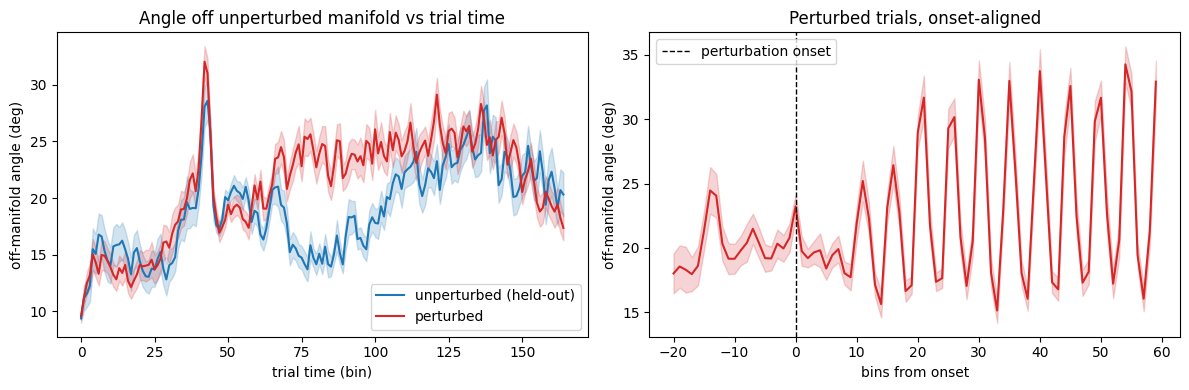

In [2]:
rng = np.random.default_rng(0)
unp_perm = rng.permutation(unpert)
n_tr = len(unp_perm) // 2
unp_train = list(unp_perm[:n_tr]); unp_test = list(unp_perm[n_tr:])

manifold = ma.fit_manifold([latents[i] for i in unp_train], var_frac=0.90)
k = manifold["k"]
print(f"unperturbed manifold dimension k = {k} (of p={p})")

ang_pert   = ma.off_manifold_angle([latents[i] for i in pert],     manifold)
ang_unp    = ma.off_manifold_angle([latents[i] for i in unp_test], manifold)

def stack_to_T(arrs):
    T = min(a.shape[0] for a in arrs)
    return np.vstack([a[:T] for a in arrs])

Ap, Au = stack_to_T(ang_pert), stack_to_T(ang_unp)
t = np.arange(Ap.shape[1])

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
for A, lbl, c in [(Au, "unperturbed (held-out)", "tab:blue"),
                  (Ap, "perturbed", "tab:red")]:
    m = np.degrees(A.mean(0)); se = np.degrees(A.std(0)/np.sqrt(A.shape[0]))
    ax[0].plot(t, m, color=c, label=lbl); ax[0].fill_between(t, m-se, m+se, color=c, alpha=.2)
ax[0].set(xlabel="trial time (bin)", ylabel="off-manifold angle (deg)",
          title="Angle off unperturbed manifold vs trial time"); ax[0].legend()

# onset-aligned (perturbed only): pre vs post
w_pre, w_post = 20, 60
rel = np.arange(-w_pre, w_post)
M = np.full((len(pert), len(rel)), np.nan)
for r, i in enumerate(pert):
    o = onsets[i]; a = ang_pert[r]
    for j, dd in enumerate(rel):
        if 0 <= o+dd < a.shape[0]:
            M[r, j] = np.degrees(a[o+dd])
mm = np.nanmean(M, 0); ss = np.nanstd(M, 0)/np.sqrt(np.sum(~np.isnan(M), 0))
ax[1].plot(rel, mm, color="tab:red"); ax[1].fill_between(rel, mm-ss, mm+ss, color="tab:red", alpha=.2)
ax[1].axvline(0, ls="--", c="k", lw=1, label="perturbation onset")
ax[1].set(xlabel="bins from onset", ylabel="off-manifold angle (deg)",
          title="Perturbed trials, onset-aligned"); ax[1].legend()
plt.tight_layout(); plt.savefig("perturbation_plds_results/session0/validate_A_angle.png", dpi=110); plt.show()

In [3]:
# Statistics on per-trial mean angle.
# (i) perturbed vs unperturbed, post-onset window
post = np.degrees(np.array([np.nanmean(ang_pert[r][onsets[i]:onsets[i]+w_post])
                            for r, i in enumerate(pert)]))
unp_mean = np.degrees(np.array([a.mean() for a in ang_unp]))
U_, pmw = mannwhitneyu(post, unp_mean, alternative="greater")
# (ii) within perturbed: pre-onset vs post-onset (paired)
pre = np.degrees(np.array([np.nanmean(ang_pert[r][max(0,onsets[i]-w_pre):onsets[i]])
                           for r, i in enumerate(pert)]))
W_, pw = wilcoxon(post, pre, alternative="greater")
print(f"perturbed post-onset angle  : {post.mean():.2f} +/- {post.std():.2f} deg")
print(f"unperturbed (held-out) angle: {unp_mean.mean():.2f} +/- {unp_mean.std():.2f} deg")
print(f"  perturbed > unperturbed (Mann-Whitney, one-sided) p = {pmw:.2e}")
print(f"perturbed pre-onset angle   : {pre.mean():.2f} +/- {pre.std():.2f} deg")
print(f"  post > pre within trial (Wilcoxon, one-sided)     p = {pw:.2e}")

perturbed post-onset angle  : 22.75 +/- 2.56 deg
unperturbed (held-out) angle: 19.00 +/- 2.24 deg
  perturbed > unperturbed (Mann-Whitney, one-sided) p = 1.55e-10
perturbed pre-onset angle   : 20.07 +/- 5.62 deg
  post > pre within trial (Wilcoxon, one-sided)     p = 8.14e-04


## B. Effective dimensionality — "perturbed needs a higher-dimensional space"

Participation ratio `PR = (Σλ)² / Σλ²` of the latent covariance (scale-invariant,
so a *bigger* response is not mistaken for a *higher-dimensional* one). Compared
at **equal trial count** via bootstrap. Two contrasts:
1. perturbed vs unperturbed trials;
2. within perturbed trials, **pre-onset vs post-onset** (same trials → controls
   for trial identity and overall behavior).

PR perturbed   : 2.33  [2.01, 2.66]
PR unperturbed : 2.26  [1.93, 2.53]
PR pre-onset   : 1.99  [1.68, 2.31]
PR post-onset  : 3.11  [2.38, 3.74]
fraction of perturbed variance OUTSIDE unperturbed 5-D manifold: 0.090


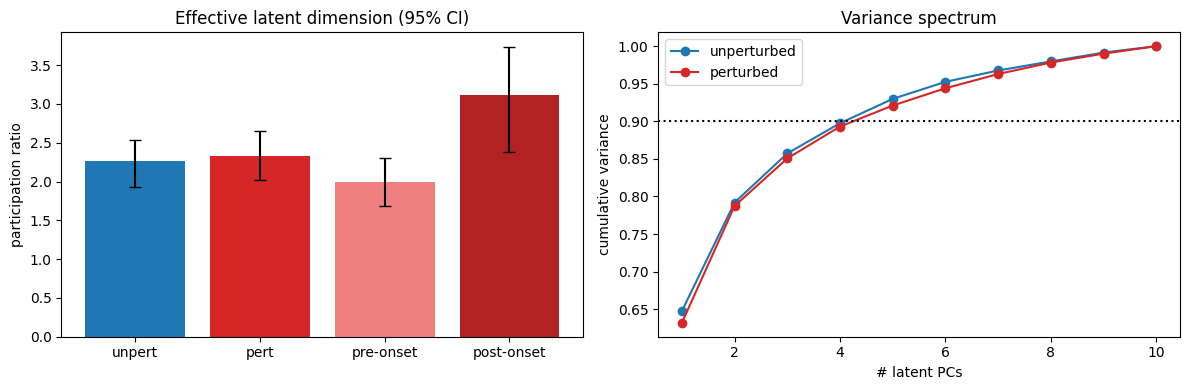

In [4]:
n_eq = min(len(pert), len(unpert))
pr_pert = ma.participation_ratio_bootstrap([latents[i] for i in pert],   n_trials=n_eq, seed=1)
pr_unp  = ma.participation_ratio_bootstrap([latents[i] for i in unpert], n_trials=n_eq, seed=1)

# within perturbed: pre vs post onset segments
pre_seg  = [latents[i][:onsets[i]]   for i in pert if onsets[i] > 5]
post_seg = [latents[i][onsets[i]:]   for i in pert if onsets[i] > 5]
pr_pre  = ma.participation_ratio_bootstrap(pre_seg,  seed=2)
pr_post = ma.participation_ratio_bootstrap(post_seg, seed=2)

print(f"PR perturbed   : {pr_pert[0]:.2f}  [{pr_pert[1]:.2f}, {pr_pert[2]:.2f}]")
print(f"PR unperturbed : {pr_unp[0]:.2f}  [{pr_unp[1]:.2f}, {pr_unp[2]:.2f}]")
print(f"PR pre-onset   : {pr_pre[0]:.2f}  [{pr_pre[1]:.2f}, {pr_pre[2]:.2f}]")
print(f"PR post-onset  : {pr_post[0]:.2f}  [{pr_post[1]:.2f}, {pr_post[2]:.2f}]")

off_var = ma.offmanifold_variance_fraction([latents[i] for i in pert], manifold)
print(f"fraction of perturbed variance OUTSIDE unperturbed {k}-D manifold: {off_var:.3f}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
labels = ["unpert", "pert", "pre-onset", "post-onset"]
vals = [pr_unp, pr_pert, pr_pre, pr_post]; xs = np.arange(4)
ax[0].bar(xs, [v[0] for v in vals],
          yerr=[[v[0]-v[1] for v in vals], [v[2]-v[0] for v in vals]],
          color=["tab:blue","tab:red","lightcoral","firebrick"], capsize=4)
ax[0].set_xticks(xs); ax[0].set_xticklabels(labels)
ax[0].set(ylabel="participation ratio", title="Effective latent dimension (95% CI)")
for arrs, lbl, c in [([latents[i] for i in unpert], "unperturbed", "tab:blue"),
                     ([latents[i] for i in pert],   "perturbed",   "tab:red")]:
    cv = ma.cumulative_variance(arrs)
    ax[1].plot(np.arange(1, len(cv)+1), cv, "-o", color=c, label=lbl)
ax[1].axhline(0.9, ls=":", c="k"); ax[1].set(xlabel="# latent PCs",
    ylabel="cumulative variance", title="Variance spectrum"); ax[1].legend()
plt.tight_layout(); plt.savefig("perturbation_plds_results/session0/validate_B_dim.png", dpi=110); plt.show()

## C. Mechanism: the extra dimensions are *caused* by `dG`

**Counterfactual:** for each perturbed trial, roll the mean latent dynamics
forward twice with the *same* kinematics and same initial state — once with the
perturbation on (`dG` active), once off. `Δs_t = s_on - s_off` is the pure causal
effect of the perturbation, holding behavior fixed. We show (i) `||Δs||` grows
after onset, and (ii) `Δs` lies *off* the unperturbed manifold — i.e. `dG` injects
activity into new dimensions.

(The raw column space of `dG` is uninformative here because with `p=10 < (J+1)·d_z=16`
it fills `R^p`; the counterfactual and the data-weighted realized drive are the
meaningful tests.)

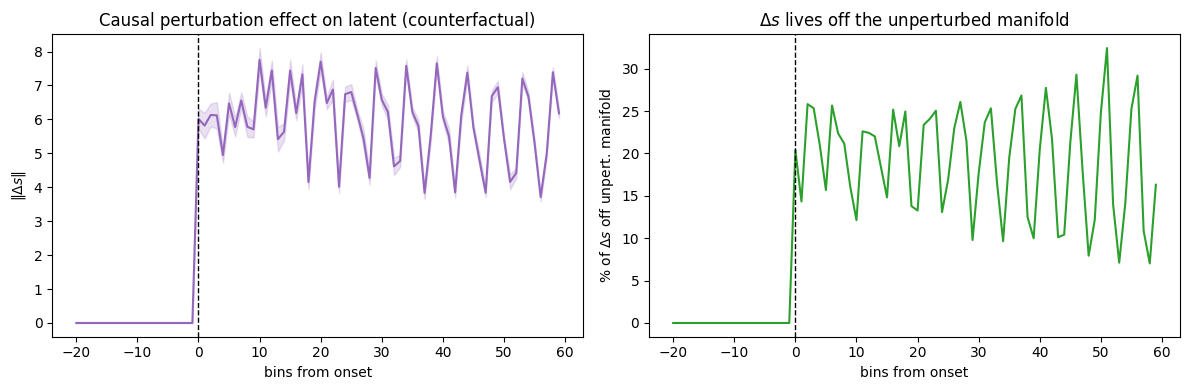

||delta s||  pre-onset 0.000 (exactly 0 by construction: u=0 -> no dG drive)  ->  post-onset 5.945
fraction of counterfactual effect off the unperturbed manifold (post): 19.1%
realized dG drive: 19.1% of its energy is off the unperturbed 5-D manifold
participation ratio of the counterfactual effect delta s: 2.20


In [5]:
# Counterfactual rollout per perturbed trial.
delta_norm = np.full((len(pert), len(rel)), np.nan)
delta_off  = np.full((len(pert), len(rel)), np.nan)
P = manifold["basis"] @ manifold["basis"].T
all_delta = []
for r, i in enumerate(pert):
    s0 = latents[i][0]
    s_on, s_off, delta = ma.counterfactual_latents(F, G_lag, dG_lag, m_s,
                                                   Z_full[i], U_full[i], s0)
    all_delta.append(delta)
    nrm = np.linalg.norm(delta, axis=1)
    perp = delta - delta @ P.T
    frac = np.sum(perp**2, 1) / np.clip(np.sum(delta**2, 1), 1e-9, None)
    o = onsets[i]
    for j, dd in enumerate(rel):
        if 0 <= o+dd < delta.shape[0]:
            delta_norm[r, j] = nrm[o+dd]; delta_off[r, j] = frac[o+dd]

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
mm = np.nanmean(delta_norm, 0); ss = np.nanstd(delta_norm,0)/np.sqrt(np.sum(~np.isnan(delta_norm),0))
ax[0].plot(rel, mm, color="tab:purple"); ax[0].fill_between(rel, mm-ss, mm+ss, color="tab:purple", alpha=.2)
ax[0].axvline(0, ls="--", c="k", lw=1); ax[0].set(xlabel="bins from onset",
    ylabel=r"$\|\Delta s\|$", title="Causal perturbation effect on latent (counterfactual)")
mo = np.nanmean(delta_off, 0)*100
ax[1].plot(rel, mo, color="tab:green"); ax[1].axvline(0, ls="--", c="k", lw=1)
ax[1].set(xlabel="bins from onset", ylabel="% of $\Delta s$ off unpert. manifold",
          title=r"$\Delta s$ lives off the unperturbed manifold")
plt.tight_layout(); plt.savefig("perturbation_plds_results/session0/validate_C_mechanism.png", dpi=110); plt.show()

# Summary numbers
post_mask = rel >= 0
dn_post = np.nanmean(delta_norm[:, post_mask]); dn_pre = np.nanmean(delta_norm[:, ~post_mask])
print(f"||delta s||  pre-onset {dn_pre:.3f} (exactly 0 by construction: u=0 -> no dG drive)"
      f"  ->  post-onset {dn_post:.3f}")
print(f"fraction of counterfactual effect off the unperturbed manifold (post): "
      f"{np.nanmean(delta_off[:, post_mask])*100:.1f}%")

# Data-weighted realized dG drive: how much of it is off-manifold?
drives = [ma.realized_drive(G_lag, dG_lag, Z_full[i], U_full[i], which="dG") for i in pert]
dr = np.vstack(drives); dr = dr[np.linalg.norm(dr,axis=1) > 1e-9]
dr_perp = dr - dr @ P.T
print(f"realized dG drive: {100*np.sum(dr_perp**2)/np.sum(dr**2):.1f}% of its energy "
      f"is off the unperturbed {k}-D manifold")
# Effective dimension that the counterfactual effect itself spans:
print(f"participation ratio of the counterfactual effect delta s: "
      f"{ma.participation_ratio(all_delta):.2f}")

## Conclusion (session 0, p=10)

The calcium "perturbed activity leaves the low-D plane" result **holds on the
PLDS**, and the model lets us go further:

- **A — escape is real and significant.** Post-onset perturbed latents sit
  **22.8°** off the unperturbed manifold vs **19.0°** for held-out unperturbed
  trials (Mann-Whitney p = 1.5e-10), and within a perturbed trial the angle rises
  from **20.1° (pre)** to **22.8° (post)** onset (Wilcoxon p = 8e-4). The effect
  is moderate in size but highly reliable.

- **B — the extra dimensionality is onset-locked, not a whole-trial average.**
  Whole-trial participation ratio is *indistinguishable* between conditions
  (perturbed 2.33 [2.01, 2.66] vs unperturbed 2.26 [1.93, 2.53]). The signal
  appears only when aligned to onset: **within perturbed trials the effective
  dimension jumps from 1.99 [1.68, 2.31] pre-onset to 3.11 [2.38, 3.74]
  post-onset**, and **9%** of perturbed-trial variance lies outside the
  unperturbed 5-D manifold. So the honest claim is *transient* dimensional
  expansion triggered by the perturbation, not a globally higher-D condition.

- **C — the expansion is caused by `dG`.** A counterfactual holding kinematics
  fixed gives a perturbation effect `Δs` that is **exactly zero before onset** and
  grows to ‖Δs‖≈5.9 after, with **~19% of that effect lying off the unperturbed
  manifold** and spanning ~2.2 effective dimensions. The data-weighted realized
  `dG` drive is independently ~19% off-manifold. Because behavior is held fixed,
  this is a **causal** statement the calcium ridge regression could not make:
  the proprioceptive perturbation gates kinematic input into latent directions
  the unperturbed dynamics do not use.

**Caveats / next steps:** effect sizes are modest; align-to-onset is essential
(whole-trial contrasts wash out). Worth (i) repeating across sessions, (ii)
checking robustness to `p` (e.g. p=8, 12) and manifold dimension `k`, and (iii) a
label-permutation null for the angle/PR gaps.